# RDKit

RDKit is an open-source cheminformatics library. It lets you:
- Parse molecules from **SMILES** strings
- Calculate **molecular properties** (mass, logP, H-bond donors/acceptors)
- Generate **2D structures**
- Compute **molecular fingerprints** for similarity searching
- Perform **substructure searches**

## <u> The chemistry package </u> 

The majority of the functionality that you will need and use in the RDKit for reading and interrogating molecular structures is found in the Chem package (rdkit.Chem). 

You may wish to look up namespaces and dot operator and how they works before we proceed any further as the functionality is found in the many and varied subpackages found within rdkit.Chem package.

If you are unsure google some of this terminology.

A list of all the subpackages can be found here: https://www.rdkit.org/docs/source/rdkit.Chem.html#module-rdkit.Chem



## <u> Importing and using RDKit </u>
    
In something as large, with as varied functionality, as the RDKit it is sensible to break its sections up into smaller and smaller units that can easily be implemented. Packages allow this to happen, they provide a heirachical structuring of the module namespace using dot notation. In the same way that modules help avoid collisions between global variable names, packages help avoid collisions between module names.
    
Therefore to use the chemistry package in RDKit we do the following:
    
<code> from rdkit import Chem </code>
    
which sets the Chem namespace. To then use the individual modules which are inside of the Chem package we do something like:
    
<code> Chem.MolFromSmiles('x') </code>
    
to use the MolFromSmiles module. We have accessed it using the aforementioned dot operator.
    
In this way we can access all the tools that we will need to carry out chemistry work in Python.

## <u> Chemical representations for computers </u>
    
Before we can use RDKit we must be able to input chemical structure into the RDKit.

Information about a chemical compound can often be gleaned directly from a chemical structure. For example a 2D structural formula or 3D coordinates for a compounds conformation will tell you a lot about how that molecule might react given certain conditions. Cheminformatics came about as a way of indexing, searching, sorting and retrieving information using these molecular structures. In order to efficiently query and work with information about thousands or even millions of these structures a computer is needed, and therefore a representation that can identify, exchange and validate this information is needed. 
    
Communicating chemical structure in a way that is palatable to both humans and machine means that a rule based system must be used. In cheminformatics, you are working within a system governed by strict rules that are explicitly defined. If you know the rules, then you can make the system work for you and you can be sure that the machine is analysing the molecule that you intended it to. 
    
In this tutorial we will only cover one way to input molecular structure into a computer, using a special form of line notation (SMILES), however there are many ways each with their own benefits and drawbacks.

## <u> Line Notation </u>
    
Line notations represent chemical structures as a linear string of symbolic characters that can be interpreted by a set of rules. They are used because computational processes can operate very effectively on data structured as linear strings and also they are reasonably desipherable to humans. Linear representations are particularly well-suited to many identification and characterization functions, such as determining:

>- whether molecules are the same 
>- how similar they are, according to some metric 
>- whether one molecular entity is a substructure of another 
>- whether two molecules are related by a specific transformation 
>- what happens when molecules are cut into pieces and grafted together at different positions 
>- In these and other applications of cheminformatics, linear representations have key advantages for speed and automation, especially when you’d like to handle huge numbers of structures (e.g. searching a large database).

Examples of line notations include the Wiswesser Line-Formula Notation (WLN), Sybyl Line Notation (SLN) and Representation of structure diagram arranged linearly (ROSDAL). Currently, the most widely used linear notations are the Simplified Molecular-Input Line-Entry System (SMILES) and the IUPAC Chemical Identifier (InChI).

## <u> Introduction to SMILES </u>

The line notation we will use in this tutorial, and in the rest of the work you do for this module, will be the SMILES string. As explained above, SMILES are a specification in the form of a <i> line notation </i> ( a typographical method using printable characters ) for describing the structure of chemical species. They are a compact human and machine-readable chemical nomenculature. 
    
SMILES contains the same information as might be found in an <i> extended connection table </i>. The primary reason SMILES is more useful than a connection table is that it is a linguistic construct, rather than a computer data structure. 

SMILES also take up less computer memory than other structure representations. A typical one will take between 50-70% of the memory in your computer than the equivalent connection table. Because of these benefits SMILES have found use in:

>- Keys for database access
>- Mechanism for researchers to exchange chemical information
>- Entry system for chemical data
>- Part of languages for artificial intelligence or expert systems in chemistry
    
SMILES represent a molecular structure as a graph with optional chiral indications. In simpler terms this is the two-dimensional picture that a chemist would draw on paper to describe a molecule. There are usually a large number of valid SMILES which represent a given structure.

## <u> Rules for SMILES </u>
    
SMILES notation consists of a series of characters containing no spaces. Hydrogen atoms are normally ommitted. Aromatic structures may be specified directly or in Kekulé form. We will describe here some of the basic rules of SMILES, this is by no means exhaustive - it is just enough to teach you the basics of RDKit. If you wish to learn more there are many online resources to help you, or please feel free to contact us asking for more information. 

See more info here - https://www.daylight.com/dayhtml/doc/theory/theory.smiles.html

Though important examples are provided below

### Atoms

Atoms are represented by their atomic symbols. The second letter of two-character symbols is entered in lower case. Elements in the "organic subset" B, C, N, O, P, S, F, Cl, Br, and I may be written without brackets if the number of attached hydrogens conforms to the lowest normal valence consistent with explicit bonds. Otherwise square brakets must be used. If an atom is in an aromatic rings then it is specified by lower case letters. So for instance an aliphatic carbon is represented by a capital C and an aromatic carbon by lower case c. As hydrogens are implied here are some examples:

In [33]:
"""This chunk creates a small dataframe that shows what SMILES symbol goes with what chemical fragment"""


identifiers = {'Chemical Identifier': ['CH4', 'PH3', 'NH3', 'H2S', 'H20', 'HCl'], 
               'SMILES symbol': ['C', 'P', 'N', 'S', 'O', 'Cl']} # A dictionary to build the dataframe from

pd.DataFrame(data = identifiers) # Builds the dataframe seen below

,Chemical Identifier,SMILES symbol
0,CH4,C
1,PH3,P
2,NH3,N
3,H2S,S
4,H20,O
5,HCl,Cl


### Bonds

Bonds are denoted as shown below:

In [34]:
""" This chunk creates a small dataframe that shows SMILES bond representations """

bond_representations = {'Bond Type': ['Single Bond', 'Double bond', 'Triple bond', 'Aromatic bond', 
                                      'Disconnected structures'],
                        
                        'SMILES representation': ['-', '=', '#', '*', '.']
                       } # Dictionary to build the data frame

pd.DataFrame(data = bond_representations) # Builds the dataframe below

,Bond Type,SMILES representation
0,Single Bond,-
1,Double bond,=
2,Triple bond,#
3,Aromatic bond,*
4,Disconnected structures,.


A single bond is the default, and so a '-' doesnt actually need to be entered. For example, 'CC' would mean that there is a non-aromatic carbon attached to another non-aromatic carbon by a single bond, and the computer would register that the chemical structure you are inputting in ethane. Note also that because both letters are capitalised it is assumed that the bond is aromatic. 

### Simple chains

Chain structures are represented by combining atomic and bond symbols. When using SMILES to represent the chains the hydrogens are suppressed. The computer will understand the number of connections that the atom can have to its surrounding atoms. It should be noted that hydrogen bonds can be explicitly identified, but once one hydrogen bond has been given, the SMILES interpreter will assume that the user has identified all hydrogens for that molecule.

Examples of chains:

In [35]:
""" This chunk creates a small dataframe that shows how we build chemical chains using SMILES """

chains = {'Chemical name': ['Ethane', 'Ethene', 'Bromoethane', 'HCl', 'Sodium Chloride'],
           'SMILES string': ['CC', 'C=C', 'CBr', 'C#N', 'Na.Cl']} #  Dictionary to build the data frame

pd.DataFrame(data = chains) # Builds the dataframe

,Chemical name,SMILES string
0,Ethane,CC
1,Ethene,C=C
2,Bromoethane,CBr
3,HCl,C#N
4,Sodium Chloride,Na.Cl


### Branching 

A branch from a chain is specified by placing the SMILES symbol(s) for the branch between parenthesis. The string in parentheses is placed directly after the symbol for the atom to which it is connected. If it is connected by a double or triple bond, the bond symbol immediately follows the left parenthesis.

In [36]:
""" This chunk creates a small dataframe that shows how branching works using SMILES """

branching = {'Chemical name': ['2-Propanol', '2-Propanone', '2-Methylbutane', '2-Methylbutanal', 
                               'Nitrobenzene', '2,2-Dimethylbutane'],
             
           'SMILES string': ['CC(O)C', 'CC(=O)C', 'CC(CC)C', 'CC(C)CC(=O)', 'c1c(N(=O)=O)cccc1',
                            'CC(C)(C)CC']} #  Dictionary to build the data frame

pd.DataFrame(data = branching) # Builds the dataframe

,Chemical name,SMILES string
0,2-Propanol,CC(O)C
1,2-Propanone,CC(=O)C
2,2-Methylbutane,CC(CC)C
3,2-Methylbutanal,CC(C)CC(=O)
4,Nitrobenzene,c1c(N(=O)=O)cccc1
5,"2,2-Dimethylbutane",CC(C)(C)CC


### Rings

Rings are constructed by using numbers to identify the opening and closing ring atom. In the string C1CCCCC1, the first carbon has the number 1 after it which connects by a single bond with the last carbon which also has a number 1 after it. This string represents cyclohexane. If multiple rings are present, each ring is identified by a different number. If a double bond is used for the ring closere, the double bond symbol is placed before the ring closure number.

Examples of rings are:

In [37]:
""" This chunk creates a small dataframe that shows how rings work using SMILES """

rings = {'Ring name': ['Cyclohexene', 'Benzene', 'Ethyloxirane', 'Naphthalene'],
             
           'SMILES string': ['C=1CCCCC1', 'c1ccccc1', 'C1OC1CC', 'c1cc2ccccc2cc1']} #  Dictionary to build the data frame

pd.DataFrame(data = rings) # Builds the dataframe

,Ring name,SMILES string
0,Cyclohexene,C=1CCCCC1
1,Benzene,c1ccccc1
2,Ethyloxirane,C1OC1CC
3,Naphthalene,c1cc2ccccc2cc1


### <u> Using the RDKit </u> 
    
Now we have loaded RDKit and have had a quick introduction to SMILES we can start using the RDKIt. 
    
To input a chemical structure into RDKIt we use the MolFromSmiles function which is inside the Chem package.
    
```python
m = Chem.MolFromSmiles('CCC')
```
    
Render an image of propane- 

Can you render all the images in the rings dataframe?

In [38]:
### your code here

#### mol files and mol objects

To understand what the mol object is you first have to understand what a mol file contains. MOL files are generally classified as data files that contain molecular data information, atom, bonds, coordinates and connectivity information in plain text format. In more technical terms, the molfile consists of three line header information, atom info in connection table, bond connections and types and sections. Put simply, they a data structure that stores molecular information.

The mol object that RDKit returns is therefore an instance of the Mol class. All this means is that they have functions and properties that they inherit just by being created. It is a data structure that contains all the information detailed above as well as giving the location of this data in your computers memory. By setting up in this way RDKit can take a mol instance as an input, and do all sorts of clever operations on it.

### <u> Quick Questions </u>

1) Print Benzene to screen \
2) Print Cyclohexene to screen \
3) Input an incorrect SMILES string, what does the error message say? How does the error message relate to the incorrect SMILES string?
4) Look up online, how would you input many molecules at once. What is the function that you would have to use? Can you import 5 different molecules here at once? \
5) Why would it be useful to import multiple molecules at once?

### Challenge questions 

Find the SMILES sctructures for - "Aspirin", "Paracetamol", "Caffeine", "Ibuprofen"

Create a dataframe with these structures

Display these structures

Write a function to lookup the following using smarts

`carboxylic_acid = Chem.MolFromSmarts("C(=O)O")   # SMARTS - Looks these up if yuo dont know`
`hydroxyl = Chem.MolFromSmarts("[OH]")              # any hydroxyl group`
`aromatic_ring = Chem.MolFromSmarts("c1ccccc1")     # benzene ring `

Add these as `True` or `FALSE` to the dictionary



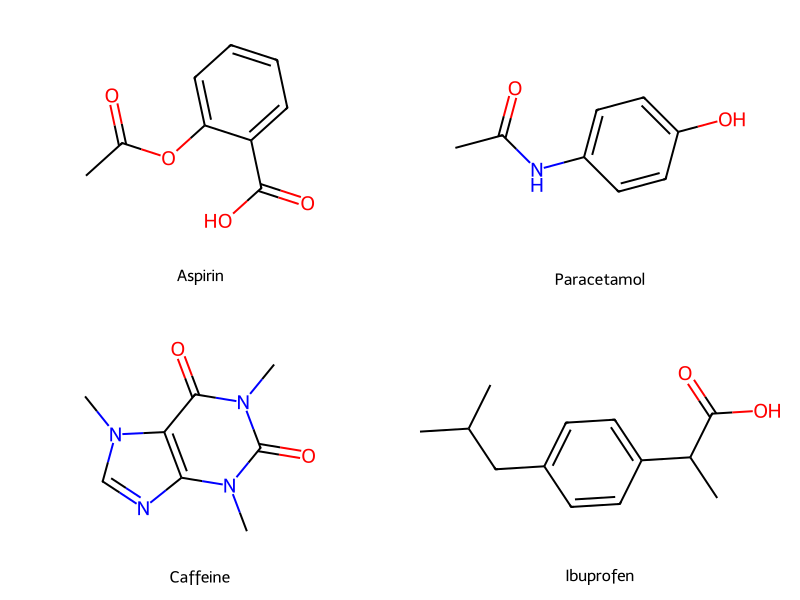

In [4]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from IPython.display import display, Image
import pandas as pd
molecules = {
    "Aspirin":      "CC(=O)Oc1ccccc1C(=O)O",
    "Paracetamol":  "CC(=O)Nc1ccc(O)cc1",
    "Caffeine":     "Cn1c(=O)c2c(ncn2C)n(c1=O)C",
    "Ibuprofen":    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Cholesterol":  "CC(C)CCCC(C)C1CCC2C1(CCC3C2CC=C4C3(CCC(C4)O)C)C",
    "Glucose":      "OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O",
    "Ethanol":      "CCO",
    "Penicillin G": "CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)Cc3ccccc3)C(=O)O)C",
}

def calculate_properties(name, smiles):
    """
    Calculate key physicochemical properties of a molecule.
    Returns a dict of properties, or None if SMILES is invalid.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return {
        "name":            name,
        "smiles":          smiles,
        "molecular_weight": round(Descriptors.MolWt(mol), 2),
        "logP":            round(Descriptors.MolLogP(mol), 2),       # lipophilicity
        "hbd":             rdMolDescriptors.CalcNumHBD(mol),          # H-bond donors
        "hba":             rdMolDescriptors.CalcNumHBA(mol),          # H-bond acceptors
        "tpsa":            round(Descriptors.TPSA(mol), 2),           # topological polar surface area
        "rotatable_bonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "aromatic_rings":  rdMolDescriptors.CalcNumAromaticRings(mol),
        "num_atoms":       mol.GetNumAtoms(),
    }

# Build a DataFrame of properties
properties_list = [calculate_properties(name, smi) for name, smi in molecules.items()]
mol_df = pd.DataFrame(properties_list)
mol_df

# Draw a grid of molecules
selected = ["Aspirin", "Paracetamol", "Caffeine", "Ibuprofen"]
mol_objects = [Chem.MolFromSmiles(molecules[name]) for name in selected]

# Generate 2D coordinates for drawing
for mol in mol_objects:
    AllChem.Compute2DCoords(mol)

img = Draw.MolsToGridImage(
    mol_objects,
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=selected
)
img

In [5]:
# Search for molecules containing a carboxylic acid group
carboxylic_acid = Chem.MolFromSmarts("C(=O)O")   # SMARTS — like SMILES but for patterns
hydroxyl = Chem.MolFromSmarts("[OH]")              # any hydroxyl group
aromatic_ring = Chem.MolFromSmarts("c1ccccc1")     # benzene ring

def has_substructure(smiles, pattern):
    mol = Chem.MolFromSmiles(smiles)
    return mol.HasSubstructMatch(pattern)

mol_df["has_COOH"]    = mol_df["smiles"].apply(lambda s: has_substructure(s, carboxylic_acid))
mol_df["has_OH"]      = mol_df["smiles"].apply(lambda s: has_substructure(s, hydroxyl))
mol_df["has_benzene"] = mol_df["smiles"].apply(lambda s: has_substructure(s, aromatic_ring))

print("Substructure search results:")
mol_df[["name", "has_COOH", "has_OH", "has_benzene"]]

Substructure search results:


,name,has_COOH,has_OH,has_benzene
0,Aspirin,True,True,True
1,Paracetamol,False,True,True
2,Caffeine,False,False,False
3,Ibuprofen,True,True,True
4,Cholesterol,False,True,False
5,Glucose,False,True,False
6,Ethanol,False,True,False
7,Penicillin G,True,True,True


# Challenge 

can you covert a SMILES to a  molfile and InChI via rdkit Mol objects?